# __Assignment 11__ : Matplotlib

## __Task 1__

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("Walmart_Sales.csv")
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [3]:
df['Weekly_Sales'] = df['Weekly_Sales'].astype('int64')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   int64  
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(4), int64(3), object(1)
memory usage: 402.3+ KB


In [4]:
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         6435 non-null   int64         
 1   Date          6435 non-null   datetime64[ns]
 2   Weekly_Sales  6435 non-null   int64         
 3   Holiday_Flag  6435 non-null   int64         
 4   Temperature   6435 non-null   float64       
 5   Fuel_Price    6435 non-null   float64       
 6   CPI           6435 non-null   float64       
 7   Unemployment  6435 non-null   float64       
dtypes: datetime64[ns](1), float64(4), int64(3)
memory usage: 402.3 KB


In [5]:
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,2010-02-05,1643690,0,42.31,2.572,211.096358,8.106
1,1,2010-02-12,1641957,1,38.51,2.548,211.242170,8.106
2,1,2010-02-19,1611968,0,39.93,2.514,211.289143,8.106
3,1,2010-02-26,1409727,0,46.63,2.561,211.319643,8.106
4,1,2010-03-05,1554806,0,46.50,2.625,211.350143,8.106


In [6]:
df_mon = df.groupby(pd.Grouper(key='Date', axis=0, freq='ME')).mean()
df_mon.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 33 entries, 2010-02-28 to 2012-10-31
Freq: ME
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         33 non-null     float64
 1   Weekly_Sales  33 non-null     float64
 2   Holiday_Flag  33 non-null     float64
 3   Temperature   33 non-null     float64
 4   Fuel_Price    33 non-null     float64
 5   CPI           33 non-null     float64
 6   Unemployment  33 non-null     float64
dtypes: float64(7)
memory usage: 2.1 KB


In [7]:
df_2010 = df_mon.loc["2010-01":"2010-12"]
df_2010['Month'] = ["February","March","April","May","June","July","August","September","October","November","December"]

C:\Users\RUPESH\AppData\Local\Temp\ipykernel_11788\2306754005.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2010['Month'] = ["February","March","April","May","June","July","August","September","October","November","December"]


## __Task 1__

## Line Chart of Sales

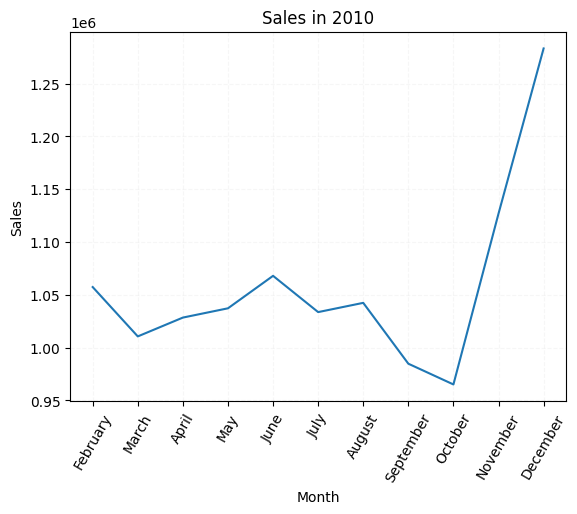

In [8]:
plt.plot(df_2010.Month,df_2010.Weekly_Sales)
plt.title('Sales in 2010')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.grid(alpha=0.1,linestyle='--')
plt.xticks(rotation=60)
plt.show()

## __Task 2__

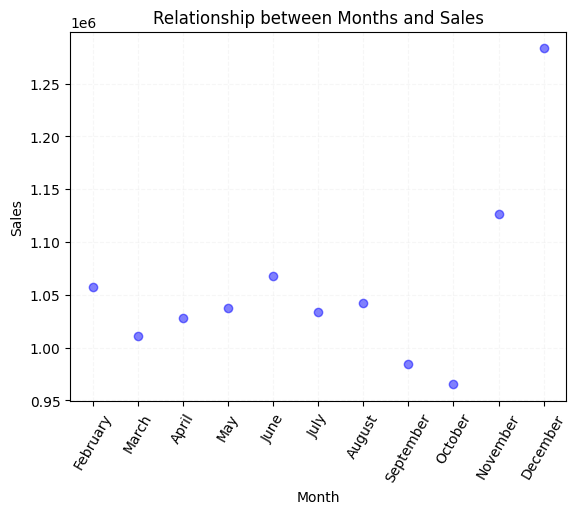

In [9]:
plt.scatter(df_2010.Month,df_2010.Weekly_Sales,color='blue',alpha=0.5)
plt.title('Relationship between Months and Sales')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.grid(alpha=0.1,linestyle='--')
plt.xticks(rotation=60)
plt.show()

## __Task 3__

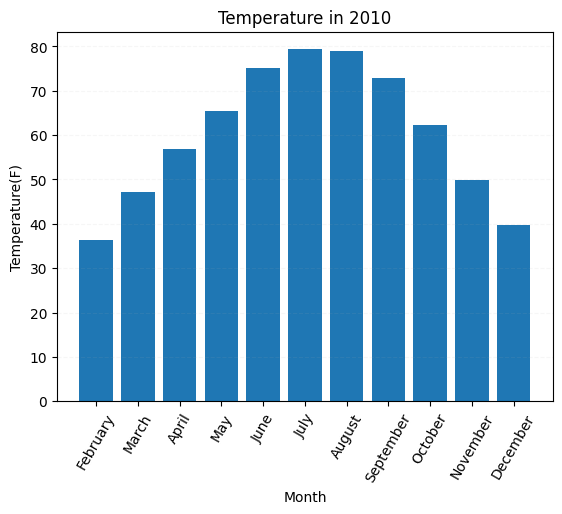

In [10]:
plt.bar(df_2010.Month,df_2010.Temperature)
plt.title('Temperature in 2010')
plt.xlabel('Month')
plt.ylabel('Temperature(F)')
plt.grid(axis='y',alpha=0.1,linestyle='--')
plt.xticks(rotation=60)
plt.show()

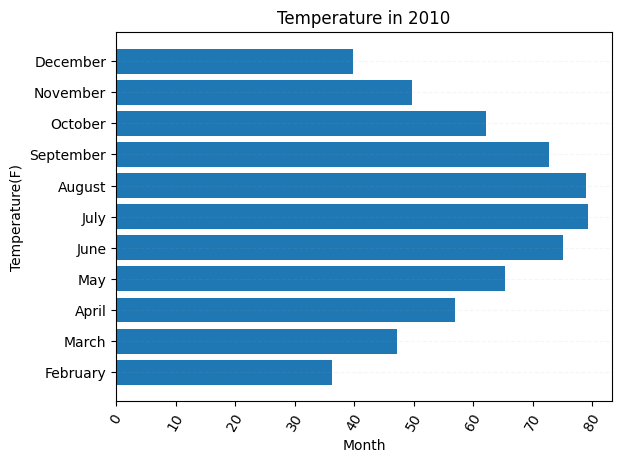

In [11]:
plt.barh(df_2010.Month,df_2010.Temperature)
plt.title('Temperature in 2010')
plt.xlabel('Month')
plt.ylabel('Temperature(F)')
plt.grid(axis='y',alpha=0.1,linestyle='--')
plt.xticks(rotation=60)
plt.show()

## __Task 4__

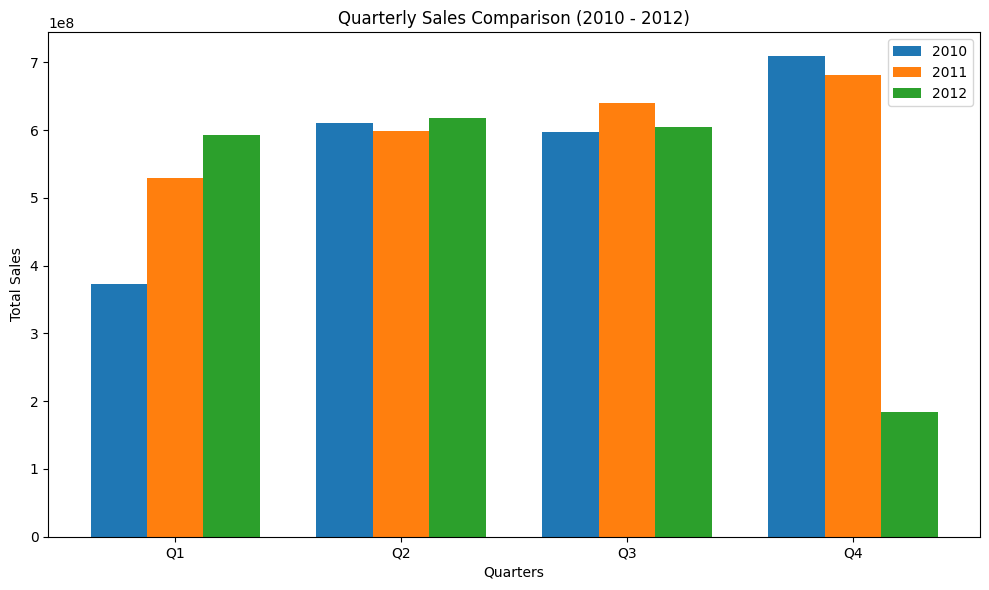

In [42]:
df['Year'] = df['Date'].dt.year
df['Quarter'] = df['Date'].dt.quarter

df_filtered = df[df['Year'].isin([2010, 2011, 2012])]

pivot_sales = df_filtered.groupby(['Quarter', 'Year'])['Weekly_Sales'].sum().unstack()

quarters = ['Q1', 'Q2', 'Q3', 'Q4']
x = np.arange(len(quarters))
width = 0.25  

plt.figure(figsize=(10, 6))

rects1 = plt.bar(x - width, pivot_sales[2010], width, label='2010')
rects2 = plt.bar(x,         pivot_sales[2011], width, label='2011')
rects3 = plt.bar(x + width, pivot_sales[2012], width, label='2012')

plt.title("Quarterly Sales Comparison (2010 - 2012)")
plt.xlabel("Quarters")
plt.ylabel("Total Sales")
plt.xticks(x, quarters)
plt.legend(title="Year")

plt.tight_layout()
plt.legend()
plt.show()

## __Task 5__

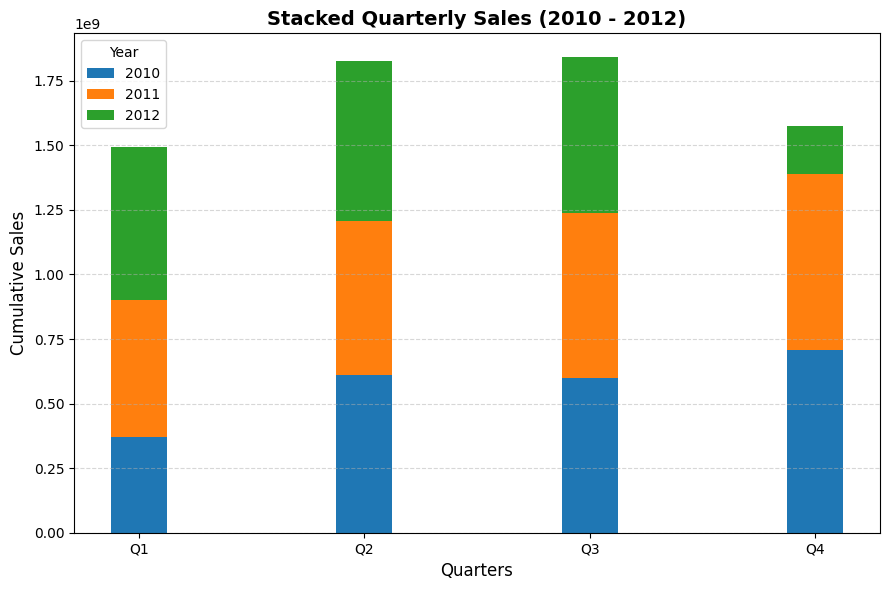

In [41]:
plt.figure(figsize=(9, 6))
bars1 = plt.bar(x, pivot_sales[2010], width, label='2010')
bars2 = plt.bar(x, pivot_sales[2011], width, bottom=pivot_sales[2010], label='2011')

total_10_11 = pivot_sales[2010] + pivot_sales[2011]

bars3 = plt.bar(x, pivot_sales[2012], width, bottom=total_10_11, label='2012')

plt.title("Stacked Quarterly Sales (2010 - 2012)", fontsize=14, fontweight='bold')
plt.xlabel("Quarters", fontsize=12)
plt.ylabel("Cumulative Sales", fontsize=12)
plt.xticks(x, quarters)
plt.legend(title="Year", loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## __Task 6__

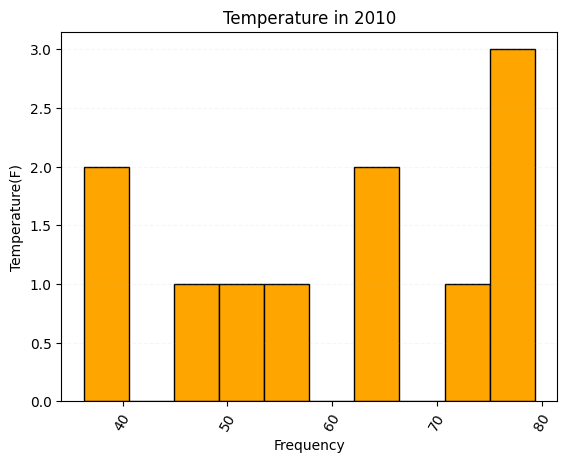

In [52]:
plt.hist(df_2010.Temperature, bins=10, color="orange",edgecolor="black")
plt.title('Temperature in 2010')
plt.xlabel('Frequency')
plt.ylabel('Temperature(F)')
plt.grid(axis='y',alpha=0.1,linestyle='--')
plt.xticks(rotation=60)
plt.show()

## __Task 7__

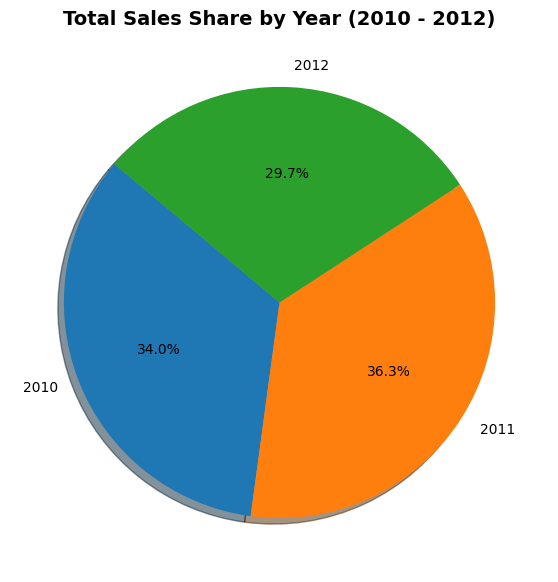

In [53]:
annual_sales = df[df['Year'].isin([2010, 2011, 2012])].groupby('Year')['Weekly_Sales'].sum().reset_index()

labels = annual_sales['Year'].astype(str)  # Convert integers to string labels
sizes = annual_sales['Weekly_Sales']
explode = (0, 0, 0.1)

plt.figure(figsize=(7,7))

plt.pie(sizes, labels=labels, autopct='%1.1f%%', shadow=True, startangle=140)  

plt.title("Total Sales Share by Year (2010 - 2012)", fontsize=14, fontweight='bold')
plt.show()